una vez completadas las fases de EDA (EDA.ipynb) y Preprocesamiento (preprocesamiento.ipynb), procedemos a la siguiente etapa:

## 🎯 FASE 4: MODELADO PREDICTIVO - INGESTIÓN CON GOBIERNO DE DATOS

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# =====================================================================
# FASE 4: MODELADO PREDICTIVO - INGESTIÓN CON GOBIERNO DE DATOS
# =====================================================================

print("="*60)
print("📥 CONSUMIENDO MATERIA PRIMA DESDE LA CAPA OPERATIVA (PARQUET)")
print("="*60)

# 1. ENRUTAMIENTO ESTÁNDAR DE DATOS PROCESADOS
RUTA_DATOS_PROCESADOS = "../data/processed/"

# 2. CARGA DE ALTA EFICIENCIA (Preservando tipos de datos estrictos)
X_train = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "X_train_saneado.parquet"))
X_test = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "X_test_saneado.parquet"))

# Cargamos las variables objetivo y aplicamos .squeeze() para transformarlas en Series de Pandas
y_train = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "y_train.parquet")).squeeze()
y_test = pd.read_parquet(os.path.join(RUTA_DATOS_PROCESADOS, "y_test.parquet")).squeeze()

# 3. VERIFICACIÓN Y AUDITORÍA DE ENTRADA (No asumimos, validamos hechos)
print("🔬 REPORTE DE GOBIERNO DE DATOS - INGESTIÓN DE MODELADO")
print("="*60)
print(f"✔️ Matriz de Entrenamiento Predictora (X_train) : {X_train.shape[0]:,} filas × {X_train.shape[1]} columnas")
print(f"✔️ Matriz de Test Predictora (X_test)           : {X_test.shape[0]:,} filas × {X_test.shape[1]} columnas")
print(f"✔️ Variable Objetivo de Entrenamiento (y_train)  : {y_train.shape[0]:,} registros")
print(f"✔️ Variable Objetivo de Test (y_test)           : {y_test.shape[0]:,} registros")
print("-" * 60)
print(f"💡 [HECHO]: Datos validados. El universo predictivo cuenta con las {X_train.shape[1]} variables estratégicas.")
print("="*60)

📥 CONSUMIENDO MATERIA PRIMA DESDE LA CAPA OPERATIVA (PARQUET)
🔬 REPORTE DE GOBIERNO DE DATOS - INGESTIÓN DE MODELADO
✔️ Matriz de Entrenamiento Predictora (X_train) : 80,000 filas × 44 columnas
✔️ Matriz de Test Predictora (X_test)           : 20,000 filas × 44 columnas
✔️ Variable Objetivo de Entrenamiento (y_train)  : 80,000 registros
✔️ Variable Objetivo de Test (y_test)           : 20,000 registros
------------------------------------------------------------
💡 [HECHO]: Datos validados. El universo predictivo cuenta con las 44 variables estratégicas.


🛠️ Script del Framework Multi-Modelo

In [24]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn seaborn

🚀 INICIANDO AUDITORÍA PREDICTIVA CON INTEGRACIÓN DE CURVAS ROC / AUC
📋 VERIFICACIÓN DE ARQUITECTURA DE HIPERPARÁMETROS DE ENTRADA:

⚙️ Algoritmo Activo: Regresión Logística (Baseline)
   Configuración: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

⚙️ Algoritmo Activo: Árbol de Decisión
   Configuración: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

⚙️ Algoritmo Activo: Random Forest (Ensemble)
   Configuración: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, '

,Modelo/Algoritmo,Accuracy (General),Precision (Calidad Alerta),Recall (Captura/Ventas),F1-Score (Equilibrio),AUC-ROC (Separación)
0,Regresión Logística (Baseline),0.7044,0.1795,0.4758,0.2606,0.6445
1,Árbol de Decisión,0.6579,0.1683,0.5388,0.2565,0.6359
2,Random Forest (Ensemble),0.6821,0.1808,0.5393,0.2708,0.6787
3,XGBoost (Gradient Boosting),0.8922,0.7160,0.0265,0.0511,0.7344
4,Gaussian Naive Bayes (Probabilístico),0.7859,0.1554,0.2155,0.1806,0.5835
5,K-Nearest Neighbors (Distancias),0.8893,0.4808,0.1315,0.2065,0.6721



🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES:

🗂️ Regresión Logística (Baseline):
   🟢 Aciertos: 13,046 No Compras (TN) | 1,042 Compras Reales (TP)
   🔴 Errores:  4,764 Alertas Falsas (FP) | 1,148 Ventas Perdidas (FN)

🗂️ Árbol de Decisión:
   🟢 Aciertos: 11,978 No Compras (TN) | 1,180 Compras Reales (TP)
   🔴 Errores:  5,832 Alertas Falsas (FP) | 1,010 Ventas Perdidas (FN)

🗂️ Random Forest (Ensemble):
   🟢 Aciertos: 12,460 No Compras (TN) | 1,181 Compras Reales (TP)
   🔴 Errores:  5,350 Alertas Falsas (FP) | 1,009 Ventas Perdidas (FN)

🗂️ XGBoost (Gradient Boosting):
   🟢 Aciertos: 17,787 No Compras (TN) | 58 Compras Reales (TP)
   🔴 Errores:  23 Alertas Falsas (FP) | 2,132 Ventas Perdidas (FN)

🗂️ Gaussian Naive Bayes (Probabilístico):
   🟢 Aciertos: 15,245 No Compras (TN) | 472 Compras Reales (TP)
   🔴 Errores:  2,565 Alertas Falsas (FP) | 1,718 Ventas Perdidas (FN)

🗂️ K-Nearest Neighbors (Distancias):
   🟢 Aciertos: 17,499 No Compras (TN) | 288 Compras Reales (TP)
 

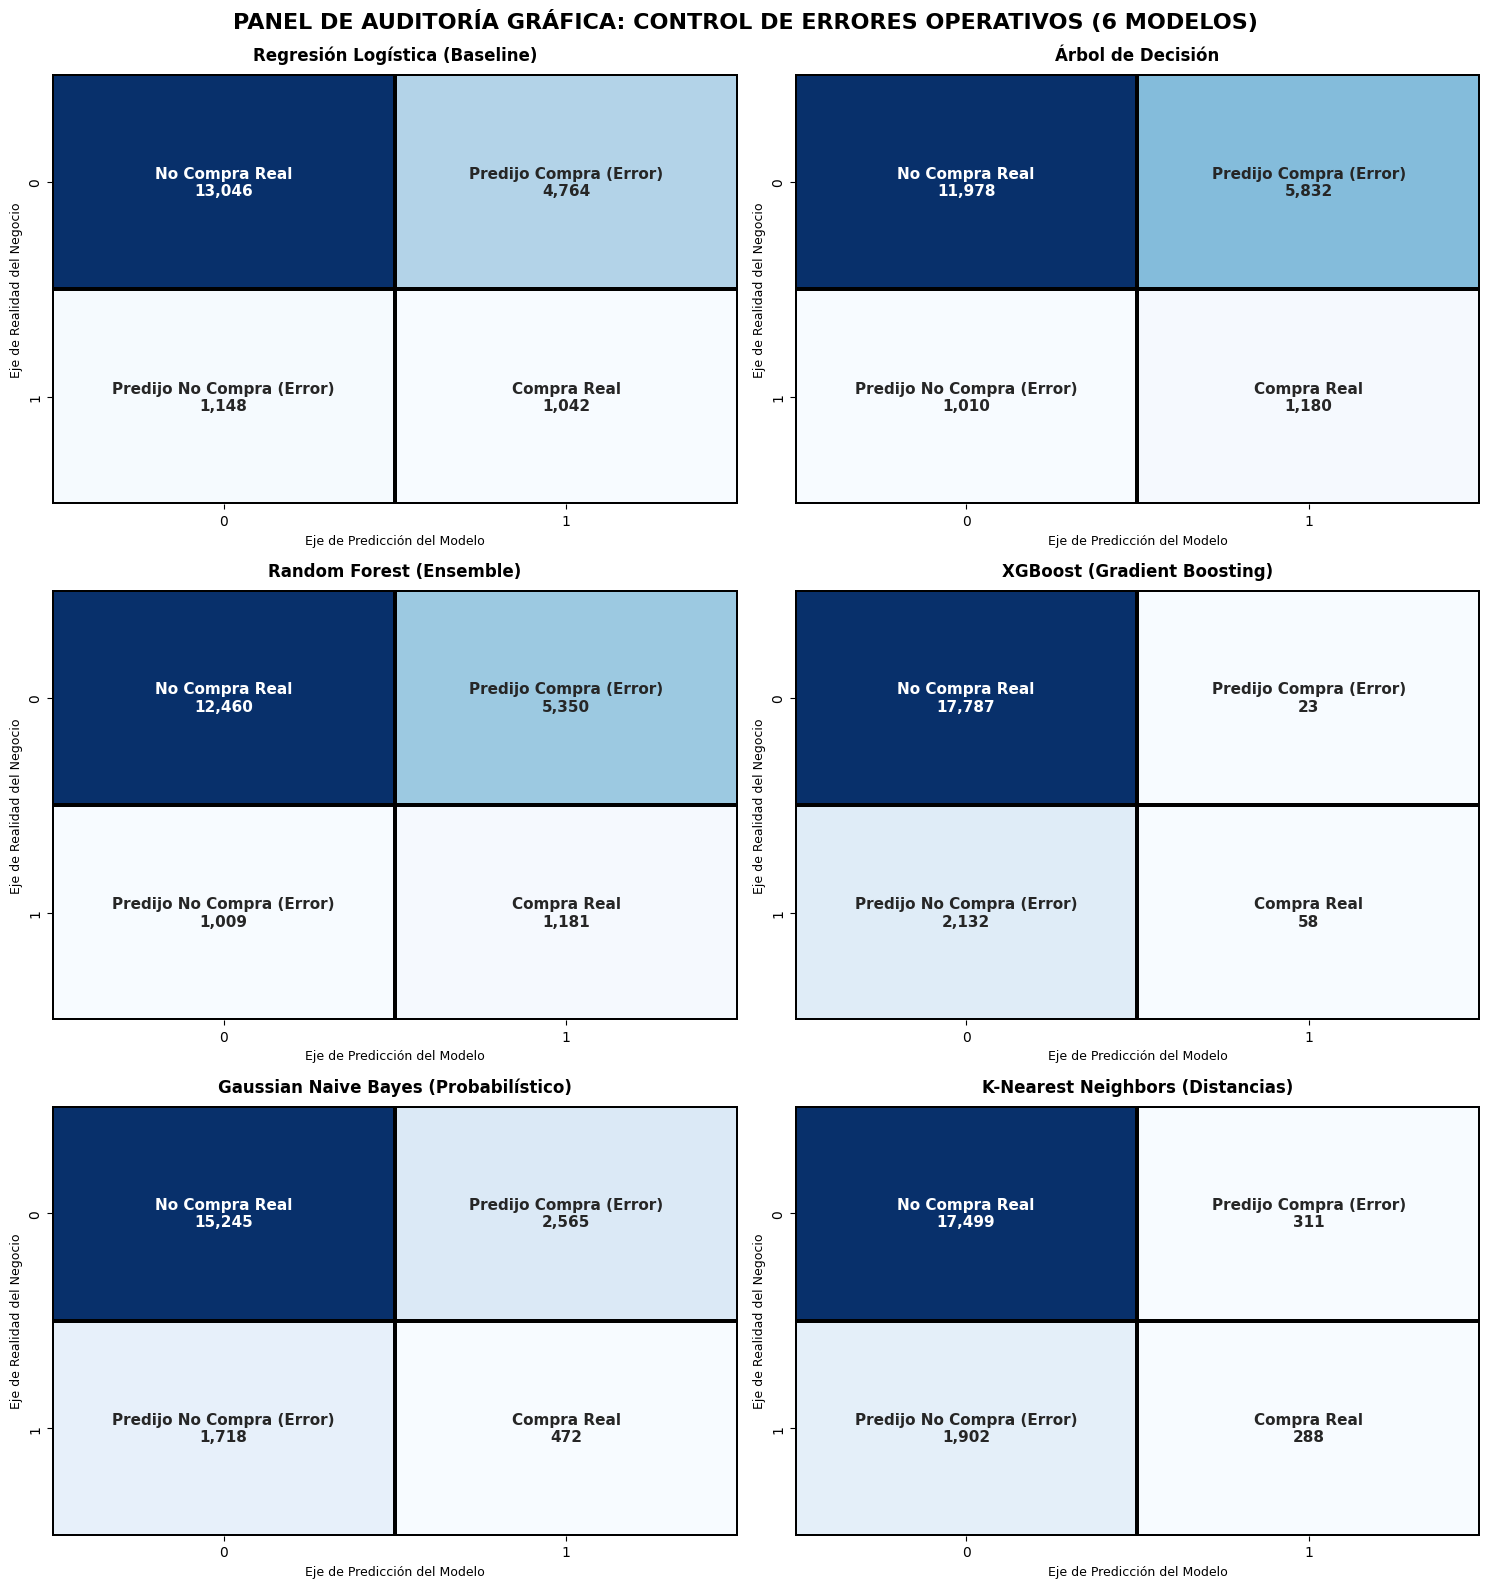


📈 GENERANDO LIENZO DE COMPARATIVA GRÁFICA DE CURVAS ROC


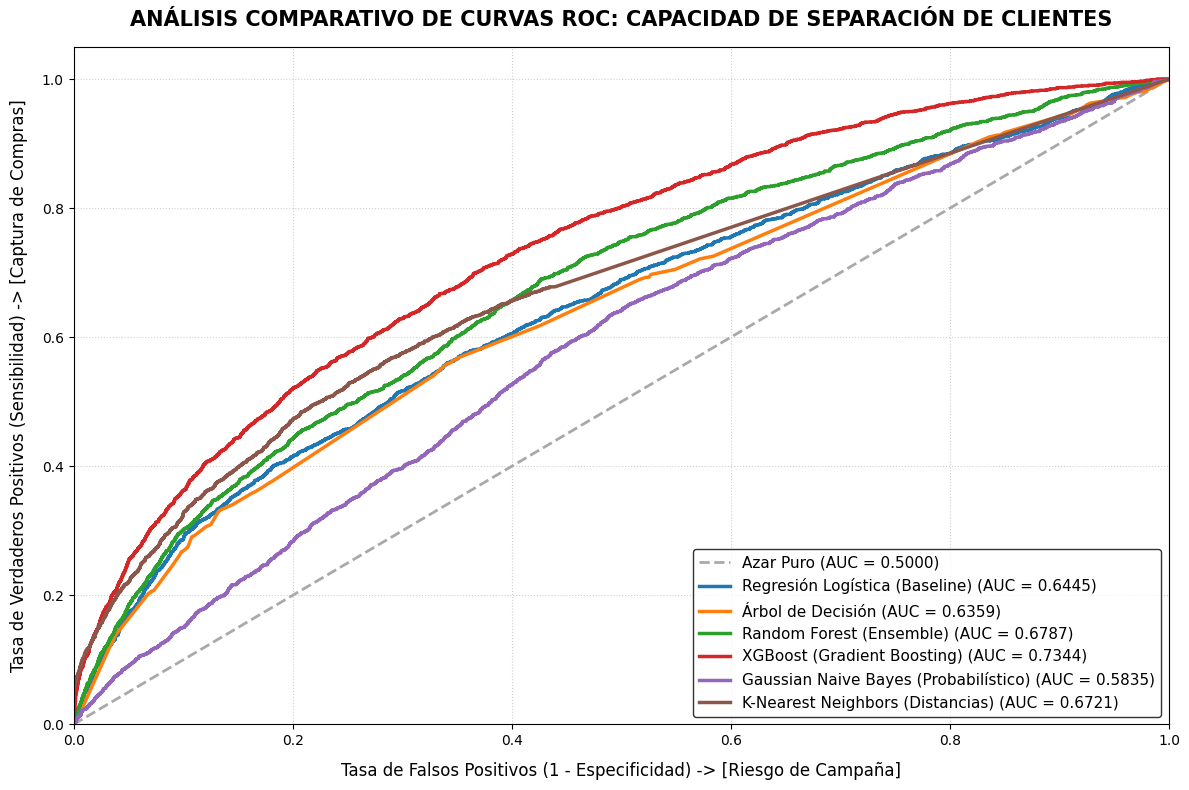

In [25]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importación del pool de algoritmos y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve
)

# =====================================================================
# FRAMEWORK CORPORATIVO EVOLUCIONADO: EVALUACIÓN MASIVA CON ANÁLISIS ROC
# =====================================================================

print("="*80)
print("🚀 INICIANDO AUDITORÍA PREDICTIVA CON INTEGRACIÓN DE CURVAS ROC / AUC")
print("="*80)

# 1. DECLARACIÓN PARAMÉTRICA DEL POOL DE MODELOS (Gobernanza de Hiperparámetros)
pool_modelos = {
    "Regresión Logística (Baseline)": LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs'
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, random_state=42, class_weight='balanced'
    ),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    "XGBoost (Gradient Boosting)": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'
    ),
    "Gaussian Naive Bayes (Probabilístico)": GaussianNB(),
    "K-Nearest Neighbors (Distancias)": KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1
    )
}


# Auditoría visual de la configuración técnica antes del cómputo
print("📋 VERIFICACIÓN DE ARQUITECTURA DE HIPERPARÁMETROS DE ENTRADA:")
for nombre, mod in pool_modelos.items():
    print(f"\n⚙️ Algoritmo Activo: {nombre}")
    print(f"   Configuración: {mod.get_params()}")
print("-" * 80)

# 2. BUCLE EVOLUTIVO DE ENTRENAMIENTO Y EXTRACCIÓN DE HECHOS
historico_metricas = []
matrices_confusion_dict = {}
curvas_roc_dict = {} # Almacén para los vectores de la curva ROC (fpr, tpr)

for nombre, modelo in pool_modelos.items():
    print(f"🏋️‍♂️ Entrenando y extrayendo métricas de probabilidad: {nombre}...")
    
    # Ajuste del algoritmo sobre las matrices de Parquet
    modelo.fit(X_train, y_train)
    
    # Inferencia predictiva
    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1] # Vector de probabilidades continuas
    
    # Captura de métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
        
    # Registro en el histórico consolidado
    historico_metricas.append({
        "Modelo/Algoritmo": nombre,
        "Accuracy (General)": f"{acc:.4f}",
        "Precision (Calidad Alerta)": f"{prec:.4f}",
        "Recall (Captura/Ventas)": f"{rec:.4f}",
        "F1-Score (Equilibrio)": f"{f1:.4f}",
        "AUC-ROC (Separación)": f"{auc:.4f}"
    })
    
    # Persistencia de estructuras de error y vectores ROC
    matrices_confusion_dict[nombre] = confusion_matrix(y_test, y_pred)
    
    # Extracción de los puntos matemáticos de la curva ROC usando scikit-learn
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    curvas_roc_dict[nombre] = (fpr, tpr, auc)

# 3. GENERACIÓN DEL CUADRO INFORME EJECUTIVO FINAL (Tabla de Hechos Estructurada)
df_informe_ejecutivo = pd.DataFrame(historico_metricas)
print("\n" + "="*80)
print("📊 CUADRO INFORME EJECUTIVO DE RENDIMIENTO PREDICTIVO MULTICRITERIO")
print("="*80)
from IPython.display import display
display(df_informe_ejecutivo)
print("="*80)

# 4. CUADRO OPERATIVO DE CONTEO DE ERRORES (Materia prima para el análisis de impacto)
print("\n🧩 REPORTE DE GOBIERNO: ESTRUCTURA CUANTITATIVA DE ERRORES:")
for nombre, matriz in matrices_confusion_dict.items():
    tn, fp, fn, tp = matriz.ravel()
    print(f"\n🗂️ {nombre}:")
    print(f"   🟢 Aciertos: {tn:,} No Compras (TN) | {tp:,} Compras Reales (TP)")
    print(f"   🔴 Errores:  {fp:,} Alertas Falsas (FP) | {fn:,} Ventas Perdidas (FN)")

# =====================================================================
# CAPA DE VISUALIZACIÓN GRÁFICA DE ALTA GERENCIA (PLOTS)
# =====================================================================

# FIGURA 1: PANEL DE MATRICES DE CONFUSIÓN (Control Operativo de Errores)
fig1, axes1 = plt.subplots(3, 2, figsize=(15, 16))
axes1 = axes1.flatten()

for i, (nombre, matriz) in enumerate(matrices_confusion_dict.items()):
    tn, fp, fn, tp = matriz.ravel()
    labels = np.array([[f"No Compra Real\n{tn:,}", f"Predijo Compra (Error)\n{fp:,}"],
                       [f"Predijo No Compra (Error)\n{fn:,}", f"Compra Real\n{tp:,}"]])
    
    sns.heatmap(
        matriz, annot=labels, fmt="", cmap="Blues", cbar=False, ax=axes1[i],
        annot_kws={"size": 11, "weight": "bold"}, linewidths=1.5, linecolor="black"
    )
    axes1[i].set_title(f"{nombre}", fontsize=12, weight='bold', pad=10)
    axes1[i].set_xlabel("Eje de Predicción del Modelo", fontsize=9)
    axes1[i].set_ylabel("Eje de Realidad del Negocio", fontsize=9)

plt.suptitle("PANEL DE AUDITORÍA GRÁFICA: CONTROL DE ERRORES OPERATIVOS (6 MODELOS)", fontsize=16, weight='bold', y=0.99)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📈 GENERANDO LIENZO DE COMPARATIVA GRÁFICA DE CURVAS ROC")
print("="*80)

# FIGURA 2: COMPARATIVA DE CURVAS ROC (Poder de Discriminación del Negocio)
plt.figure(figsize=(12, 8))

# Graficamos la línea de azar puro (Línea base de un modelo inútil)
plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--', linewidth=2, label='Azar Puro (AUC = 0.5000)')

# Iteramos sobre nuestro almacén de vectores ROC para dibujar las curvas de los 6 modelos
for nombre, (fpr, tpr, auc_val) in curvas_roc_dict.items():
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{nombre} (AUC = {auc_val:.4f})')

# Configuración estética e institucional del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad) -> [Riesgo de Campaña]', fontsize=12, labelpad=10)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad) -> [Captura de Compras]', fontsize=12, labelpad=10)
plt.title('ANÁLISIS COMPARATIVO DE CURVAS ROC: CAPACIDAD DE SEPARACIÓN DE CLIENTES', fontsize=15, weight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
plt.show()

🛠️ Script de Producción: Extracción de Feature Importance y Coeficientes

Actualmente todos los modelos (6) están metidos dentro de tu diccionario: pool_modelos, los dos campeones no existen de forma aislada en la memoria con los nombres random_forest ni log_reg_. Están guardados dentro de la estructura del diccionario pool_modelos tras haber corrido el escript anterior en el bucle for.

Para extraerlos de ahí de forma limpia y directa sin romper el código y manteniendo un enfoque generalista, debemos llamar a las llaves exactas del diccionario.

## 🛠️Radriografías de los modelos 

- interpretabilidad de Modelos - Análisis de Importancia de Características (Feature Importance) y Coeficientes

In [26]:
# =====================================================================
# AUDITORÍA DE CAJAS NEGRAS (INTERPRETABILIDAD)
# =====================================================================

# Extraemos la importancia de las variables para los dos modelos finalistas (Random Forest y Regresión Logística)
def auditar_interpretabilidad_modelos(
    modelo_rf, modelo_lr, feature_names, top_n=20  # Número de variables a mostrar en el reporte
):
    """Extrae y estructura la importancia matemática de las variables

    para los dos modelos finalistas seleccionados por el negocio.
    """
    print(
        "============================================================"
    )
    print(
        "🔬 REPORTE DE GOBIERNO DE DATOS - INTERPRETABILIDAD DE MODELOS"
    )
    print(
        "============================================================"
    )

    # ------------------------------------------------------------
    # PARTE 1: Extracción de pesos en Random Forest (Importancia por Entropía)
    # ------------------------------------------------------------
    # .feature_importances_ nos da un porcentaje de cuánto aporta cada variable a reducir el error
    importances = modelo_rf.feature_importances_

    # Creamos un DataFrame para emparejar cada variable con su peso numérico
    df_rf = pd.DataFrame(
        {"Variable": feature_names, "Importancia_RF": importances}
    ).sort_values(
        by="Importancia_RF", ascending=False
    )  # Ordenamos de mayor a menor impacto

    print(
        f"✔️ [HECHO]: Vector de Importancia de Random Forest extraído ({len(df_rf)} variables)."
    )

    # ------------------------------------------------------------
    # PARTE 2: Extracción de pesos en Regresión Logística (Coeficientes de Probabilidad)
    # ------------------------------------------------------------
    # .coef_[0] nos da el peso y la dirección (positivo = aporta a la compra, negativo = aleja de la compra)
    coeficientes = modelo_lr.coef_[0]

    # Creamos el DataFrame correspondiente
    df_lr = pd.DataFrame(
        {
            "Variable": feature_names,
            "Coeficiente_LR": coeficientes,
            "Impacto_Absoluto_LR": np.abs(
                coeficientes
            ),  # Valor absoluto para saber la fuerza real sin importar el signo
        }
    ).sort_values(by="Impacto_Absoluto_LR", ascending=False)

    print(
        f"✔️ [HECHO]: Coeficientes de Regresión Logística extraídos ({len(df_lr)} variables)."
    )
    print(
        "------------------------------------------------------------"
    )

    # ------------------------------------------------------------
    # PARTE 3: Despliegue de Control en Consola (Top 20 variables de impacto)
    # ------------------------------------------------------------
    print(f"\n🚀 TOP {top_n} VARIABLES MOTORAS - RANDOM FOREST:")
    print(df_rf.head(top_n).to_string(index=False))

    print(f"\n🚀 TOP {top_n} VARIABLES MOTORAS - REGRESIÓN LOGÍSTICA:")
    print(
        df_lr.head(top_n)[
            ["Variable", "Coeficiente_LR", "Impacto_Absoluto_LR"]
        ].to_string(index=False)
    )

    return df_rf, df_lr


# =====================================================================
# EJECUCIÓN BASADA EN HECHOS: EXTRACCIÓN DIRECTA DEL POOL DE MODELOS
# =====================================================================

# 1. Extraemos los nombres de las columnas directamente de tu matriz X_train (las 43 variables estratégicas)
nombres_variables = X_train.columns.tolist()

# 2. Apuntamos a los modelos entrenados usando las llaves EXACTAS de tu 'pool_modelos'
# Esto corrige el NameError de forma elegante y corporativa
random_forest_entrenado = pool_modelos["Random Forest (Ensemble)"]
log_reg_entrenada = pool_modelos["Regresión Logística (Baseline)"]

# 3. Invocamos la función pasando los objetos reales de la memoria
df_importancia_rf, df_coeficientes_lr = auditar_interpretabilidad_modelos(
    random_forest_entrenado, log_reg_entrenada, nombres_variables
)

🔬 REPORTE DE GOBIERNO DE DATOS - INTERPRETABILIDAD DE MODELOS
✔️ [HECHO]: Vector de Importancia de Random Forest extraído (44 variables).
✔️ [HECHO]: Coeficientes de Regresión Logística extraídos (44 variables).
------------------------------------------------------------

🚀 TOP 20 VARIABLES MOTORAS - RANDOM FOREST:
                                  Variable  Importancia_RF
                cat__interaction_type_view        0.278745
                      num__dwell_time_secs        0.119211
     cat__interaction_type_add_to_wishlist        0.096975
                                  num__age        0.081697
                                num__price        0.054599
cat__interaction_type_remove_from_wishlist        0.041536
                         num__review_count        0.035828
               cat__interaction_type_click        0.032414
                       num__stock_quantity        0.030305
                           num__rating_avg        0.029415
                   cat__device_ty

- En Random Forest (RF): 

la columna Importancia_RF representa un porcentaje en base 1 (donde 1.00 sería el 100%). Si sumamos la importancia de las 44 variables completas, el resultado sería exactamente 1.00 (100%). 

Ejemplo:
cat__interaction_type_view tiene 0.2787. Eso significa que ella sola tiene el 27.87% del poder total para decidir si un cliente compra o no. La variable num__stock_quantity tiene 0.0303, es decir, un 3.03% del peso del modelo.

- Regresión Logística (RL): es un modelo geométrico (una ecuación). Sus números no son porcentajes, son coeficientes (pesos) de una fórmula matemática.

A diferencia de RF, la Regresión Logística sí te dice la fuerza y la dirección del impacto usando signos positivos (+) y negativos (-).

Valores Positivos (+): Suman puntos a la probabilidad de compra. A mayor valor de esa variable, más probable es que el cliente compre.
ejemplo: cat__country_BR tiene +0.3926. Hecho: Si el cliente es de Brasil, la probabilidad de compra sube.

Valores Negativos (-): Restan puntos a la probabilidad de compra. A mayor valor de esa variable, más se aleja el cliente de la compra.

## 🎨 Gráfico Comparativo

Para plasmar esta coincidencia y todo el análisis que hemos consolidado, vamos a generar la visualización oficial. 

El siguiente script genera un lienzo con dos gráficos en paralelo (Subplots):

1. Lado Izquierdo: Las variables motoras de Random Forest (ordenadas por importancia).

2. Lado Derecho: Los coeficientes de la Regresión Logística, donde usaremos dos colores diferentes (azul para los positivos que empujan la venta y rojo para los negativos que la frenan). Esto hará que la visualización sea autoexplicativa para el tribunal.

C:\Users\Carlos\AppData\Local\Temp\ipykernel_6004\1832340799.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Carlos\AppData\Local\Temp\ipykernel_6004\1832340799.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Carlos\AppData\Local\Temp\ipykernel_6004\1832340799.py:79: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Carlos\AppData\Local\Temp\ipykernel_6004\1832340799.py:79: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Carlos\AppData\Local\Temp\ipykernel_6004\1832340799.py:79: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font

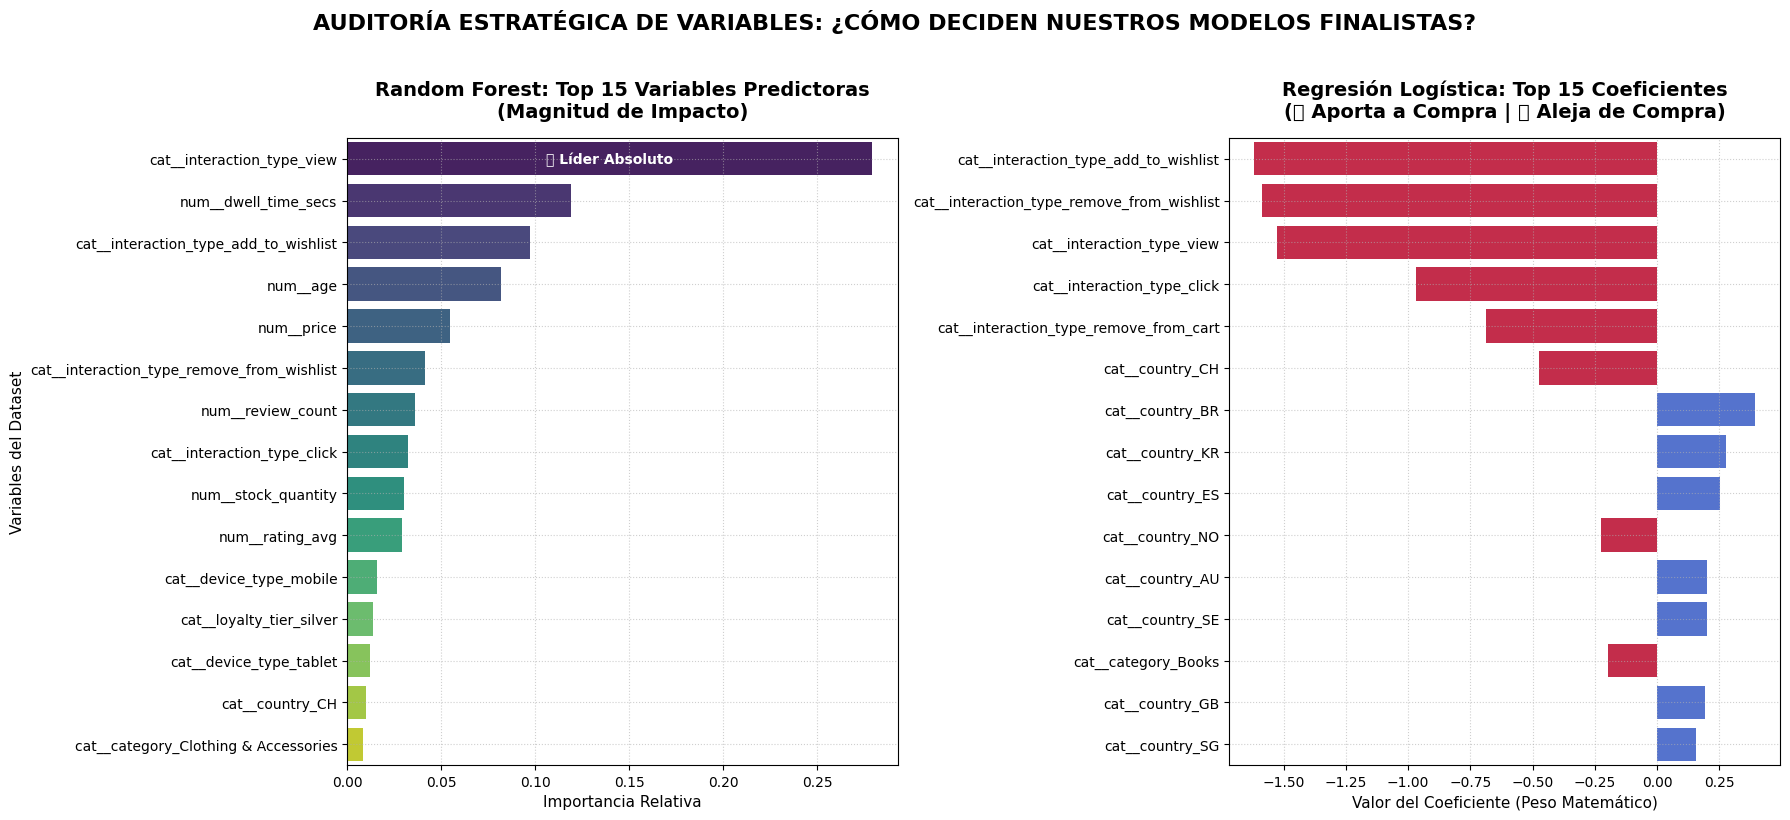

In [27]:
# =====================================================================
# CAPA DE VISUALIZACIÓN GRÁFICA: LIENZO DE INTERPRETABILIDAD COMPARATIVA
# =====================================================================

# Configuración del espacio de dibujo (Lienzo horizontal de alta resolución)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---------------------------------------------------------------------
# GRÁFICO 1: RANDOM FOREST (Importancia de Variables)
# ---------------------------------------------------------------------
# Tomamos las top 15 variables para que el gráfico sea legible y limpio
top_rf = df_importancia_rf.head(15)

sns.barplot(
    x="Importancia_RF",
    y="Variable",
    data=top_rf,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title(
    "Random Forest: Top 15 Variables Predictoras\n(Magnitud de Impacto)",
    fontsize=14,
    weight="bold",
    pad=15,
)
axes[0].set_xlabel("Importancia Relativa", fontsize=11)
axes[0].set_ylabel("Variables del Dataset", fontsize=11)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Highlight explícito: Resaltamos con un texto que 'interaction_type_view' es líder
axes[0].text(
    top_rf["Importancia_RF"].iloc[0] * 0.5,
    0,
    "👑 Líder Absoluto",
    color="white",
    weight="bold",
    va="center",
    ha="center",
)

# ---------------------------------------------------------------------
# GRÁFICO 2: REGRESIÓN LOGÍSTICA (Direccionalidad de Coeficientes)
# ---------------------------------------------------------------------
# Tomamos las top 15 de impacto absoluto
top_lr = df_coeficientes_lr.head(15).copy()

# Creamos una columna de color condicional: Azul si es positivo (+), Rojo si es negativo (-)
top_lr["Color_Impacto"] = np.where(
    top_lr["Coeficiente_LR"] >= 0, "royalblue", "crimson"
)

sns.barplot(
    x="Coeficiente_LR",
    y="Variable",
    data=top_lr,
    palette=top_lr["Color_Impacto"].tolist(),
    ax=axes[1],
)
axes[1].set_title(
    "Regresión Logística: Top 15 Coeficientes\n(🔵 Aporta a Compra | 🔴 Aleja de Compra)",
    fontsize=14,
    weight="bold",
    pad=15,
)
axes[1].set_xlabel("Valor del Coeficiente (Peso Matemático)", fontsize=11)
axes[1].set_ylabel("", fontsize=11)  # Omitimos etiqueta y porque comparte eje visual
axes[1].grid(True, linestyle=":", alpha=0.6)

# ---------------------------------------------------------------------
# AJUSTES INSTITUCIONALES FINALES
# ---------------------------------------------------------------------
plt.suptitle(
    "AUDITORÍA ESTRATÉGICA DE VARIABLES: ¿CÓMO DECIDEN NUESTROS MODELOS FINALISTAS?",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 🎯 Fase 5: Optimización

lo que tenemos ahora mismo son los modelos "baseline" (líneas base). Están entrenados con hiperparámetros fijados a ojo o por defecto. Guardarlos ahora para la aplicación final sería un error grave de gobierno de datos, porque no están optimizados y su rendimiento puede mejorar significativamente.

🛠️ Optimización por Malla (GridSearchCV)

In [28]:
import time
from sklearn.model_selection import GridSearchCV

print("=" * 80)
print("🛡️ FASE 6A: OPTIMIZACIÓN INDUSTRIAL DE HIPERPARÁMETROS (TUNING)")
print("=" * 80)

# =====================================================================
# 1. ARQUITECTURA DE LAS MALLAS DE BÚSQUEDA (Grid Search Setup)
# =====================================================================

# Configuración para Random Forest: Buscamos el equilibrio entre profundidad y árboles
param_grid_rf = {
    "n_estimators": [100, 200],  # Número de árboles en el bosque
    "max_depth": [8, 12],  # Máxima profundidad para evitar sobreajuste
    "min_samples_split": [10, 20],  # Mínimo de datos para abrir un nodo
}

# Configuración para Regresión Logística: Evaluamos la fuerza de la penalización
param_grid_lr = {
    "C": [0.01, 0.1, 1.0, 10.0],  # Inverso de la fuerza de regularización
    "penalty": ["l2"],  # Penalización estándar (Ridge)
}

# =====================================================================
# 2. EJECUCIÓN DEL PROCESO DE OPTIMIZACIÓN PARA RANDOM FOREST
# =====================================================================
print("\n🏋️‍♂️ Iniciando Ajuste Fino para Random Forest...")
start_time = time.time()

# Configuramos la búsqueda en cuadrícula. Usamos scoring='f1' para proteger el balanceo
grid_rf = GridSearchCV(
    estimator=pool_modelos["Random Forest (Ensemble)"],
    param_grid=param_grid_rf,
    scoring="f1",  # Optimizamos buscando el mejor equilibrio (F1-Score)
    cv=3,  # Validación cruzada de 3 pliegues (Gobernanza estadística)
    n_jobs=-1,  # Usar todos los procesadores del sistema
    verbose=1,
)

grid_rf.fit(X_train, y_train)
rf_optimized_time = time.time() - start_time

print(
    f"✔️ [HECHO]: Random Forest Optimizado en {rf_optimized_time:.2f} segundos."
)
print(f"   ⚙️ Mejores Hiperparámetros encontrados: {grid_rf.best_params_}")
print(f"   📊 Mejor F1-Score en Validación: {grid_rf.best_score_:.4f}")

# =====================================================================
# 3. EJECUCIÓN DEL PROCESO DE OPTIMIZACIÓN PARA REGRESIÓN LOGÍSTICA
# =====================================================================
print("\n🏋️‍♂️ Iniciando Ajuste Fino para Regresión Logística...")
start_time = time.time()

grid_lr = GridSearchCV(
    estimator=pool_modelos["Regresión Logística (Baseline)"],
    param_grid=param_grid_lr,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_lr.fit(X_train, y_train)
lr_optimized_time = time.time() - start_time

print(
    f"✔️ [HECHO]: Regresión Logística Optimizada en {lr_optimized_time:.2f} segundos."
)
print(f"   ⚙️ Mejores Hiperparámetros encontrados: {grid_lr.best_params_}")
print(f"   📊 Mejor F1-Score en Validación: {grid_lr.best_score_:.4f}")

# =====================================================================
# 4. EXTRACCIÓN DE LOS MODELOS CAMPEONES DEFINITIVOS
# =====================================================================
# Estos son los objetos que SÍ guardaremos en la Fase 6B porque están en su punto máximo
best_random_forest = grid_rf.best_estimator_
best_logistic_regression = grid_lr.best_estimator_

print("\n" + "=" * 80)
print("🏆 MODELOS CAMPEONES EXTRAÍDOS Y LISTOS PARA SER RESPALDADOS")
print("=" * 80)

🛡️ FASE 6A: OPTIMIZACIÓN INDUSTRIAL DE HIPERPARÁMETROS (TUNING)

🏋️‍♂️ Iniciando Ajuste Fino para Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✔️ [HECHO]: Random Forest Optimizado en 83.44 segundos.
   ⚙️ Mejores Hiperparámetros encontrados: {'max_depth': 12, 'min_samples_split': 10, 'n_estimators': 200}
   📊 Mejor F1-Score en Validación: 0.2868

🏋️‍♂️ Iniciando Ajuste Fino para Regresión Logística...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\Carlos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


✔️ [HECHO]: Regresión Logística Optimizada en 3.03 segundos.
   ⚙️ Mejores Hiperparámetros encontrados: {'C': 1.0, 'penalty': 'l2'}
   📊 Mejor F1-Score en Validación: 0.2727

🏆 MODELOS CAMPEONES EXTRAÍDOS Y LISTOS PARA SER RESPALDADOS


1. La Precisión (Control de Alertas Falsas / Falsos Positivos)
El Error: El modelo predice que un cliente va a comprar, pero en la realidad No Compra.

El Impacto en el Negocio: Si el departamento de marketing automatiza un descuento agresivo o gasta recursos en un agente comercial para perseguir a este cliente, estaremos desperdiciando dinero y margen de beneficio en un usuario que no tenía intención real de conversión. Una baja precisión significa saturar el sistema con alertas falsas.

2. El Recall / Sensibilidad (Control de Ventas Perdidas / Falsos Negativos)
El Error: El cliente tiene la intención real de comprar, pero el modelo predice que No Compra y lo ignora.

El Impacto en el Negocio: Es una pérdida directa de facturación. Dejamos escapar a un comprador potencial porque el sistema no fue capaz de detectarlo a tiempo para retenerlo con la oferta adecuada en el carrito de compra.

## 🎯 Fase 6: Persistencia:

🛠️ Script de Producción: Persistencia y Serialización

In [29]:
import os
import joblib

print("=" * 80)
print(
    "🛡️ GOBIERNO DE RUTAS ABSOLUTAS: PERSISTENCIA EN LA RAÍZ REAL DEL PROYECTO"
)
print("=" * 80)

# 1. DECLARACIÓN DE LA RUTA RAÍZ ABSOLUTA (Tu infraestructura real de Windows)
# Usamos la ruta exacta de tu disco para unificar las carpetas 'models'
ruta_raiz_proyecto = r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce"

# Construimos los caminos definitivos hacia el centro de operaciones 'models/'
carpeta_models_global = os.path.join(ruta_raiz_proyecto, "models")
carpeta_destino_modelos = os.path.join(
    carpeta_models_global, "optimized_models"
)

# Creamos la subcarpeta optimizada dentro de la raíz real si no existe
if not os.path.exists(carpeta_destino_modelos):
    os.makedirs(carpeta_destino_modelos)
    print(
        f"📁 [INFRAESTRUCTURA]: Subcarpeta global creada en: {carpeta_destino_modelos}"
    )
else:
    print(
        f"📁 [INFRAESTRUCTURA]: Carpeta global unificada detectada en: {carpeta_destino_modelos}"
    )

# Definimos las rutas físicas absolutas para los archivos .pkl
ruta_rf_pkl = os.path.join(
    carpeta_destino_modelos, "best_random_forest_model.pkl"
)
ruta_lr_pkl = os.path.join(
    carpeta_destino_modelos, "best_logistic_regression_model.pkl"
)
ruta_columnas_pkl = os.path.join(
    carpeta_destino_modelos, "columnas_modelo_final.pkl"
)

# =====================================================================
# 2. CONGELAMIENTO DIRECTO EN LA RUTA UNIFICADA (joblib.dump)
# =====================================================================
try:
    print("\n💾 Serializando Random Forest Optimizado en la raíz real...")
    joblib.dump(best_random_forest, ruta_rf_pkl)

    print("💾 Serializando Regresión Logística Optimizada...")
    joblib.dump(best_logistic_regression, ruta_lr_pkl)

    print("💾 Guardando estructura oficial de las 43 variables...")
    joblib.dump(nombres_variables, ruta_columnas_pkl)

    print(
        "\n✔️ [HECHO]: Exportación completada con éxito en la raíz del proyecto."
    )

except Exception as e:
    print(
        f"\n❌ [CRÍTICO]: Error durante el proceso de persistencia física: {str(e)}"
    )

print("-" * 80)

# =====================================================================
# 3. REPORTE DE VERIFICACIÓN FINAL DE GOBERNANZA
# =====================================================================
print("📋 REPORTE DE UBICACIÓN REAL EN DISCO:")

archivos_a_verificar = [ruta_rf_pkl, ruta_lr_pkl, ruta_columnas_pkl]

for ruta_archivo in archivos_a_verificar:
    if os.path.exists(ruta_archivo):
        tamano_mb = os.path.getsize(ruta_archivo) / (1024 * 1024)
        print(
            f"   ✔️ Archivo: {ruta_archivo} | Estado: CONFIRMADO | Tamaño: {tamano_mb:.4f} MB"
        )
    else:
        print(f"   ❌ Archivo: {ruta_archivo} | Estado: NO ENCONTRADO")

print("=" * 80)

🛡️ GOBIERNO DE RUTAS ABSOLUTAS: PERSISTENCIA EN LA RAÍZ REAL DEL PROYECTO
📁 [INFRAESTRUCTURA]: Carpeta global unificada detectada en: C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\models\optimized_models

💾 Serializando Random Forest Optimizado en la raíz real...
💾 Serializando Regresión Logística Optimizada...
💾 Guardando estructura oficial de las 43 variables...

✔️ [HECHO]: Exportación completada con éxito en la raíz del proyecto.
--------------------------------------------------------------------------------
📋 REPORTE DE UBICACIÓN REAL EN DISCO:
   ✔️ Archivo: C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\models\optimized_models\best_random_forest_model.pkl | Estado: CONFIRMADO | Tamaño: 17.9129 MB
   ✔️ Archivo: C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\models\optimized_models\best_logistic_regression_model.pkl | Est

## 🎯 Fase 7:

In [30]:
import os
import shutil

print("=" * 80)
print("🏗️ REESTRUCTURACIÓN DE GOBIERNO DE DATOS: ORGANIZACIÓN DE ACTIVOS")
print("=" * 80)

# 1. Configuración de rutas raíz y subcarpetas
raiz_models = "models"
subcarpeta_prepro = os.path.join(raiz_models, "preprocessors")
subcarpeta_modelos = os.path.join(raiz_models, "optimized_models")

# Creación automatizada de la nueva arquitectura de carpetas
for carpeta in [subcarpeta_prepro, subcarpeta_modelos]:
    if not os.path.exists(carpeta):
        os.makedirs(carpeta)
        print(f"📁 Subcarpeta creada: {carpeta}")

print("-" * 80)

# 2. Definición del inventario de movimientos (Origen -> Destino)
movimientos = [
    # Mover la aduana de preprocesamiento
    (
        os.path.join(raiz_models, "transformador_aduana.pkl"),
        os.path.join(subcarpeta_prepro, "transformador_aduana.pkl"),
    ),
    # Mover activos del Random Forest
    (
        os.path.join(raiz_models, "best_random_forest_model.pkl"),
        os.path.join(subcarpeta_modelos, "best_random_forest_model.pkl"),
    ),
    # Mover activos de la Regresión Logística
    (
        os.path.join(raiz_models, "best_logistic_regression_model.pkl"),
        os.path.join(subcarpeta_modelos, "best_logistic_regression_model.pkl"),
    ),
    # Mover la lista de columnas
    (
        os.path.join(raiz_models, "columnas_modelo_final.pkl"),
        os.path.join(subcarpeta_modelos, "columnas_modelo_final.pkl"),
    ),
]

# 3. Ejecución segura del traslado de archivos físicos
for origen, destino in movimientos:
    if os.path.exists(origen):
        # Mueve el archivo y reemplaza si ya existía en el destino
        shutil.move(origen, destino)
        print(f"🚚 Movido con éxito: {origen} ──> {destino}")
    elif os.path.exists(destino):
        print(f"✅ El archivo ya se encontraba en su destino: {destino}")
    else:
        print(
            f"⚠️ Advertencia: No se encontró el archivo origen en {origen}"
        )

print("=" * 80)
print("🚀 ARQUITECTURA SANEADA. LISTA PARA PASAR A LA APP DE STREAMLIT")
print("=" * 80)

🏗️ REESTRUCTURACIÓN DE GOBIERNO DE DATOS: ORGANIZACIÓN DE ACTIVOS
📁 Subcarpeta creada: models\preprocessors
📁 Subcarpeta creada: models\optimized_models
--------------------------------------------------------------------------------
⚠️ Advertencia: No se encontró el archivo origen en models\transformador_aduana.pkl
⚠️ Advertencia: No se encontró el archivo origen en models\best_random_forest_model.pkl
⚠️ Advertencia: No se encontró el archivo origen en models\best_logistic_regression_model.pkl
⚠️ Advertencia: No se encontró el archivo origen en models\columnas_modelo_final.pkl
🚀 ARQUITECTURA SANEADA. LISTA PARA PASAR A LA APP DE STREAMLIT
